In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Telco.csv")

In [4]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

# Remove customer ID because it isn't useful for prediction
X = X.drop("customerID", axis=1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [5]:
# i will build 3 pipelines

In [6]:
#logistic regression
# Decision tree and knn

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score
import time

In [8]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [9]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [10]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [11]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [12]:
#training all 3 models and measuring performances


In [16]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [21]:
y = y.map({"No": 0, "Yes": 1})

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
import time
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "KNN": knn_pipeline
}

results = []

for name, pipeline in models.items():

    start_time = time.time()

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    training_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1": f1,
        "Training Time (seconds)": training_time
    })

results_df = pd.DataFrame(results)

results_df

C:\Users\Shoaib Akbar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Shoaib Akbar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Shoaib Akbar\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Shoaib Akbar\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~

,Model,Accuracy,F1,Training Time (seconds)
0,Logistic Regression,0.805536,0.604046,0.238114
1,Decision Tree,0.725337,0.494118,0.075461
2,KNN,0.757275,0.547619,0.161724


In [24]:
# what i think here is logistic regression performed beset based on both accuracy and f1 score

In [25]:
# DT was fast but had lowest accuracy and f1 score.

In [26]:
# KNN was in the middle for both f1 and accuracy 

In [27]:
# Task  2 inerpretability

In [28]:
lr_model = lr_pipeline.named_steps["model"]

feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()

lr_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_[0]
})

lr_coefficients["Direction"] = lr_coefficients["Coefficient"].apply(
    lambda x: "Churn" if x > 0 else "Retention"
)

lr_coefficients = lr_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

lr_coefficients

,Feature,Coefficient,Direction
17,cat__InternetService_Fiber optic,0.642696,Churn
37,cat__Contract_Month-to-month,0.587223,Churn
2,num__TotalCharges,0.509768,Churn
36,cat__StreamingMovies_Yes,0.209811,Churn
33,cat__StreamingTV_Yes,0.209038,Churn
44,cat__PaymentMethod_Electronic check,0.204871,Churn
19,cat__OnlineSecurity_No,0.165204,Churn
28,cat__TechSupport_No,0.140770,Churn
15,cat__MultipleLines_Yes,0.111415,Churn
41,cat__PaperlessBilling_Yes,0.042282,Churn


In [29]:
top_3_lr = lr_coefficients.head(3)

top_3_lr

,Feature,Coefficient,Direction
17,cat__InternetService_Fiber optic,0.642696,Churn
37,cat__Contract_Month-to-month,0.587223,Churn
2,num__TotalCharges,0.509768,Churn


In [30]:
bottom_3_lr = lr_coefficients.tail(3)

bottom_3_lr

,Feature,Coefficient,Direction
16,cat__InternetService_DSL,-0.639980,Retention
39,cat__Contract_Two year,-0.762517,Retention
0,num__tenure,-1.233313,Retention


In [31]:
# DT feature importance


In [32]:
dt_model = dt_pipeline.named_steps["model"]

dt_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_importance

,Feature,Importance
2,num__TotalCharges,0.192519
1,num__MonthlyCharges,0.186502
37,cat__Contract_Month-to-month,0.166082
0,num__tenure,0.118382
17,cat__InternetService_Fiber optic,0.052756
44,cat__PaymentMethod_Electronic check,0.021307
4,cat__gender_Male,0.017514
28,cat__TechSupport_No,0.015281
22,cat__OnlineBackup_No,0.014029
40,cat__PaperlessBilling_No,0.013861


In [37]:
top_3_dt = dt_importance.head(3)

top_3_dt

,Feature,Importance
2,num__TotalCharges,0.192519
1,num__MonthlyCharges,0.186502
37,cat__Contract_Month-to-month,0.166082


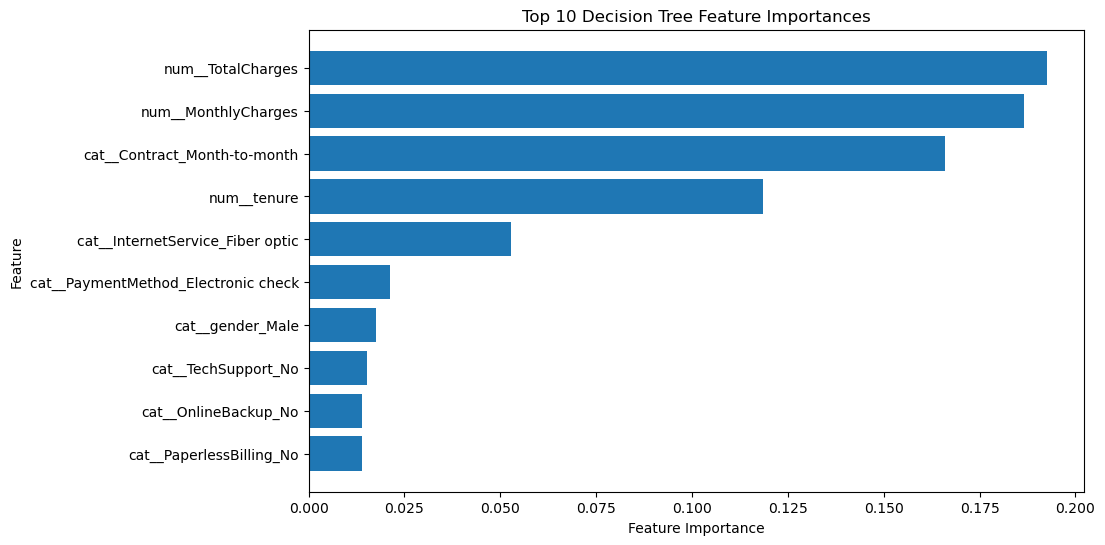

In [33]:
import matplotlib.pyplot as plt

top_10_dt = dt_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_dt["Feature"][::-1],
    top_10_dt["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Decision Tree Feature Importances")

plt.show()

In [34]:
# now i will compare the top3

In [35]:
top_3_lr

,Feature,Coefficient,Direction
17,cat__InternetService_Fiber optic,0.642696,Churn
37,cat__Contract_Month-to-month,0.587223,Churn
2,num__TotalCharges,0.509768,Churn


In [38]:
top_3_dt

,Feature,Importance
2,num__TotalCharges,0.192519
1,num__MonthlyCharges,0.186502
37,cat__Contract_Month-to-month,0.166082


In [39]:
# they agree on 2 of the top 3 features here which is total charges and contract - month to month

In [40]:
#LR and DT models agree that total charges and M2M contract are amonth the top churn drivers but they disagree on the third driver.

In [41]:
#LR IDENTIFIES FIBER Optic service while DT indetifies monthly charges which means that the tree maybe capturing non linear relationship which linear model does not

In [42]:
#TASK 3 class balance check


In [43]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [44]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [45]:
# the dataset is imbalanced with 73% customers in the non churn class and 26% in churn, the accuracy may not fully represent model performance
# making f1 score more important for evaluating churn predictionms